In [1]:
import cv2
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt

#### https://courses.cs.washington.edu/courses/cse455/09wi/Lects/lect16.pdf


# All metrics used were either in mm or pixels

# Train data: 101 examples

In [2]:
manual_dist = pd.read_csv("train_data_manual_entry.csv", header=0)
manual_dist =manual_dist.astype(int)

left_imgs = glob.glob('./train_undistorted_rectified/*left.jpeg')
right_imgs = glob.glob('./train_undistorted_rectified/*right.jpeg')
print(len(left_imgs))
left_imgs.sort()
right_imgs.sort()
count = 0

depth_to_disparity = open("train_depth_to_disparity.csv", "w")
depth_to_px_width = open("train_depth_to_px_width.csv", "w")
depth_to_px_height = open("train_depth_to_px_height.csv", "w")

square_size =  70

for left, right in zip(left_imgs, right_imgs):
    current_dist = int(left.split("\\")[-1].split("_")[0])
    
    left_rectified  = cv2.imread(left)
    right_rectified  = cv2.imread(right)

    # NONE DET
    
    coordinates = manual_dist[manual_dist['dist'] == current_dist].iloc[0]
    xl_1 = coordinates['xl_1']
    yl_1 = coordinates['yl_1']
    cv2.circle(left_rectified, (xl_1, yl_1), 4, (255, 255, 255), 2, 2)
    xl_2  = coordinates['xl_2']
    yl_2 = coordinates['yl_2']
    cv2.circle(left_rectified, (xl_2, yl_2), 4, (0, 255, 255), 2, 2)
    xl_3  = coordinates['xl_3']
    yl_3 = coordinates['yl_3']
    cv2.circle(left_rectified, (xl_3, yl_3), 4, (0, 0, 255), 2, 2)
    xr_1 = coordinates['xr_1']
    yr_1 = coordinates['yr_1']
    cv2.circle(right_rectified, (xr_1, yr_1), 4, (255, 255, 255), 2, 2)
    xr_2 = coordinates['xr_2']
    yr_2 = coordinates['yr_2']
    cv2.circle(right_rectified, (xr_2, yr_2), 4, (0, 255, 255), 2, 2)
    xr_3  = coordinates['xr_3']
    yr_3 = coordinates['yr_3']
    cv2.circle(right_rectified, (xr_3, yr_3), 4, (0, 0, 255), 2, 2)
    count+=1
    
    #cv2.imshow(f'{current_dist}_left', left_rectified)
    #cv2.imshow(f'{current_dist}_right', right_rectified)
    
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()
    
    depth_to_disparity.write(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
    px_width = xl_1-xl_3 
    px_height = yl_1 - yl_2
    #print((f"{current_dist}, {px_width}, {px_height} \n"))
    px_width_mm = abs(square_size/px_width)
    px_height_mm = abs(square_size/px_height)
    #print((f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n"))
    depth_to_px_width.write(f"{current_dist}, {px_width_mm}\n")
    depth_to_px_height.write(f"{current_dist}, {px_height_mm} \n")



depth_to_disparity.close()
depth_to_px_width.close()
depth_to_px_height.close()
print(count)

101
101


In [3]:
df_dist_vs_disparity_train = pd.read_csv("train_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_train = pd.read_csv("train_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_train = pd.read_csv("train_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

Text(0, 0.5, 'x disparity(px)')

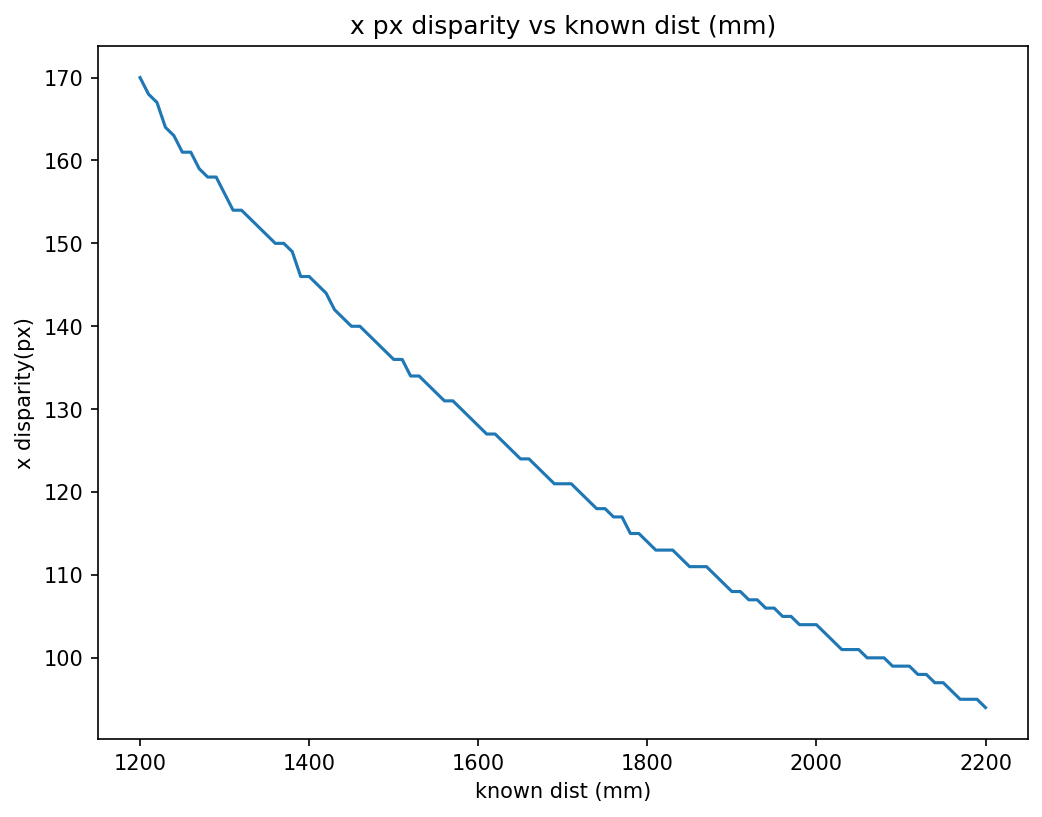

In [4]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_dist_vs_disparity_train['dist_mm'], df_dist_vs_disparity_train['x_disparity_px'])
plt.title('x px disparity vs known dist (mm)')
plt.xlabel("known dist (mm)")
plt.ylabel("x disparity(px)")

Text(0, 0.5, 'pixel_width_mm)')

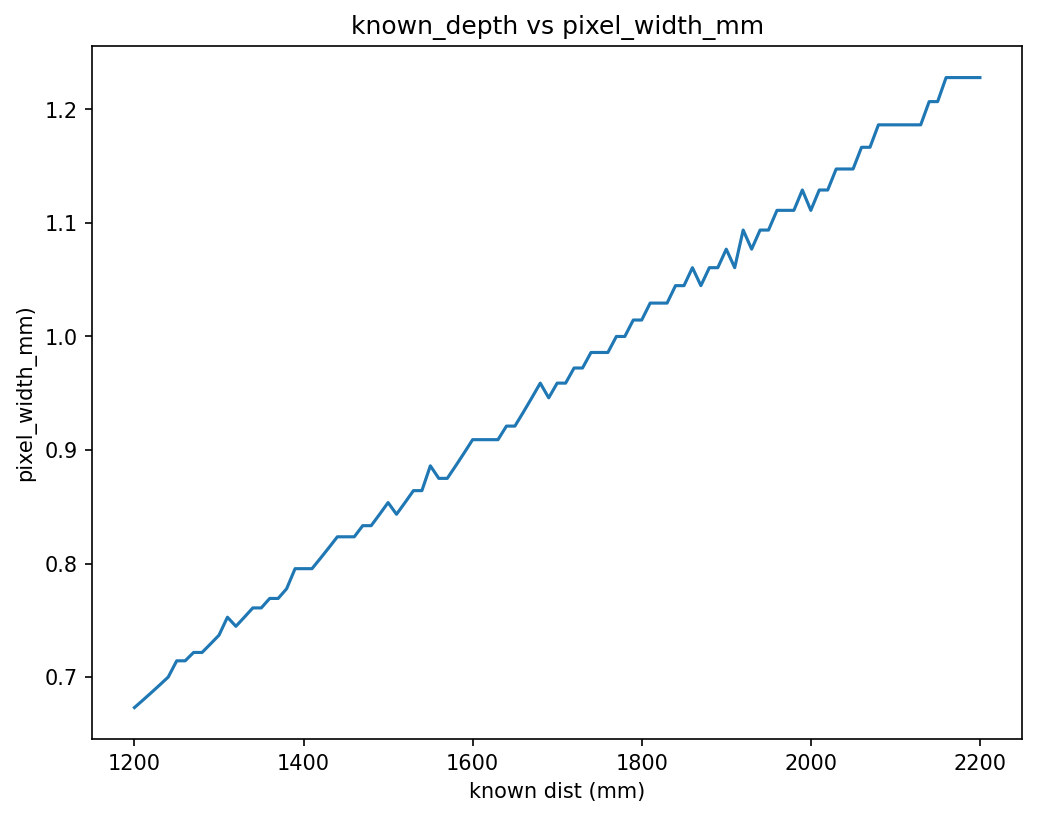

In [5]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_width_train['dist_mm'], df_depth_vs_px_width_train['pixel_width_mm'])
plt.title('known_depth vs pixel_width_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_width_mm)")

Text(0, 0.5, 'pixel_height_mm)')

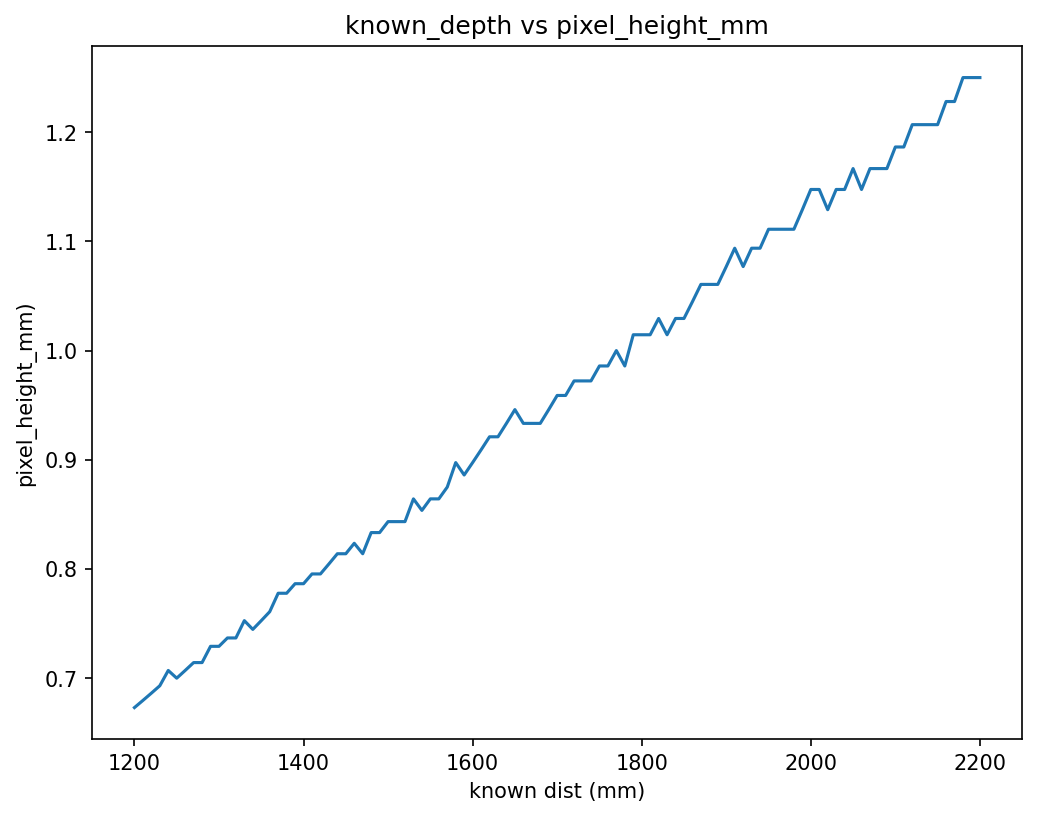

In [6]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_height_train['dist_mm'], df_depth_vs_px_height_train['pixel_height_mm'])
plt.title('known_depth vs pixel_height_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_height_mm)")

# Test data: 25 examples

In [7]:
manual_dist = pd.read_csv("test_data_manual_entry.csv", header=0)
manual_dist =manual_dist.astype(int)

left_imgs = glob.glob('./test_undistorted_rectified/*left.jpeg')
right_imgs = glob.glob('./test_undistorted_rectified/*right.jpeg')
print(len(left_imgs))
left_imgs.sort()
right_imgs.sort()
count = 0

depth_to_disparity = open("test_depth_to_disparity.csv", "w")
depth_to_px_width = open("test_depth_to_px_width.csv", "w")
depth_to_px_height = open("test_depth_to_px_height.csv", "w")

square_size =  70

for left, right in zip(left_imgs, right_imgs):
    current_dist = int(left.split("\\")[-1].split("_")[0])
    
    left_rectified  = cv2.imread(left)
    right_rectified  = cv2.imread(right)

    # NONE DET
    
    coordinates = manual_dist[manual_dist['dist'] == current_dist].iloc[0]
    xl_1 = coordinates['xl_1']
    yl_1 = coordinates['yl_1']
    cv2.circle(left_rectified, (xl_1, yl_1), 4, (255, 255, 255), 2, 2)
    xl_2  = coordinates['xl_2']
    yl_2 = coordinates['yl_2']
    cv2.circle(left_rectified, (xl_2, yl_2), 4, (0, 255, 255), 2, 2)
    xl_3  = coordinates['xl_3']
    yl_3 = coordinates['yl_3']
    cv2.circle(left_rectified, (xl_3, yl_3), 4, (0, 0, 255), 2, 2)
    xr_1 = coordinates['xr_1']
    yr_1 = coordinates['yr_1']
    cv2.circle(right_rectified, (xr_1, yr_1), 4, (255, 255, 255), 2, 2)
    xr_2 = coordinates['xr_2']
    yr_2 = coordinates['yr_2']
    cv2.circle(right_rectified, (xr_2, yr_2), 4, (0, 255, 255), 2, 2)
    xr_3  = coordinates['xr_3']
    yr_3 = coordinates['yr_3']
    cv2.circle(right_rectified, (xr_3, yr_3), 4, (0, 0, 255), 2, 2)
    count+=1

    #cv2.imshow(f'{current_dist}_left', left_rectified)
    #cv2.imshow(f'{current_dist}_right', right_rectified)

    #cv2.waitKey(0)
    #cv2.destroyAllWindows()
    
    depth_to_disparity.write(f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n")
    px_width = xl_1-xl_3 
    px_height = yl_1 - yl_2
    #print((f"{current_dist}, {px_width}, {px_height} \n"))
    px_width_mm = abs(square_size/px_width)
    px_height_mm = abs(square_size/px_height)
    #print((f"{current_dist}, {xl_1-xr_1}, {yl_1-yr_1} \n"))
    depth_to_px_width.write(f"{current_dist}, {px_width_mm}\n")
    depth_to_px_height.write(f"{current_dist}, {px_height_mm} \n")


depth_to_disparity.close()
depth_to_px_width.close()
depth_to_px_height.close()
print(count)

25
25


In [8]:
df_dist_vs_disparity_test = pd.read_csv("test_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_test = pd.read_csv("test_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_test = pd.read_csv("test_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

Text(0, 0.5, 'x disparity(px)')

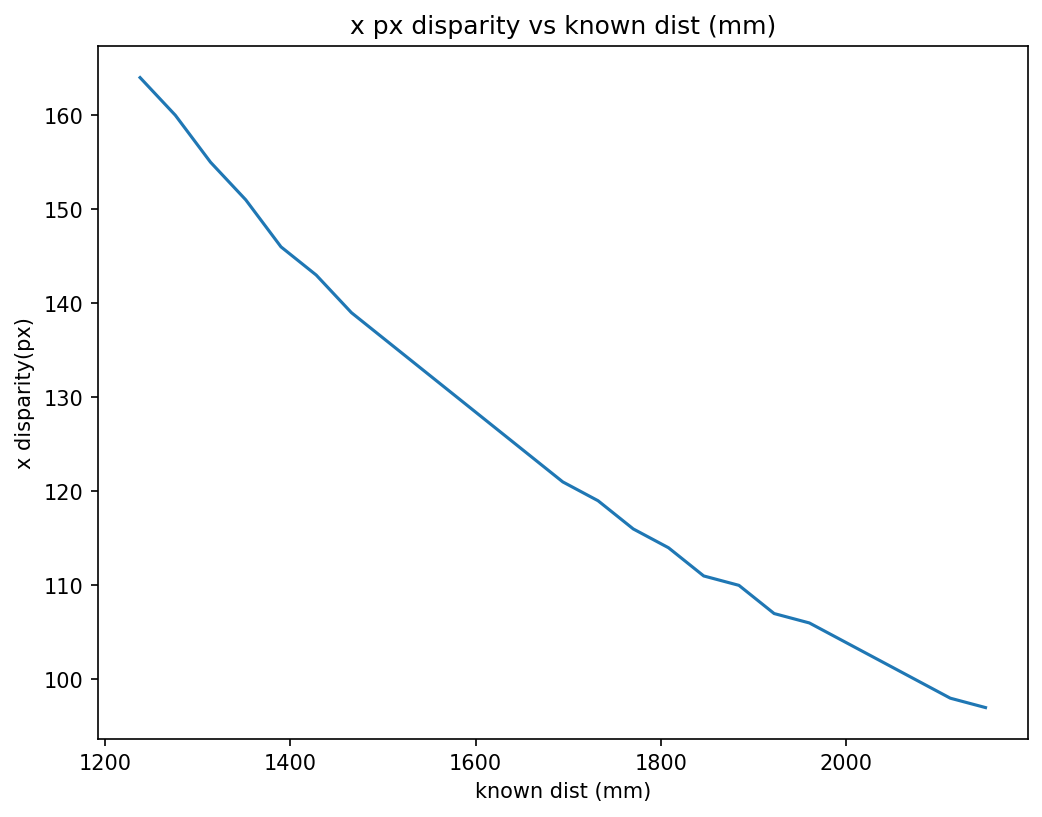

In [9]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_dist_vs_disparity_test['dist_mm'], df_dist_vs_disparity_test['x_disparity_px'])
plt.title('x px disparity vs known dist (mm)')
plt.xlabel("known dist (mm)")
plt.ylabel("x disparity(px)")

Text(0, 0.5, 'pixel_width_mm)')

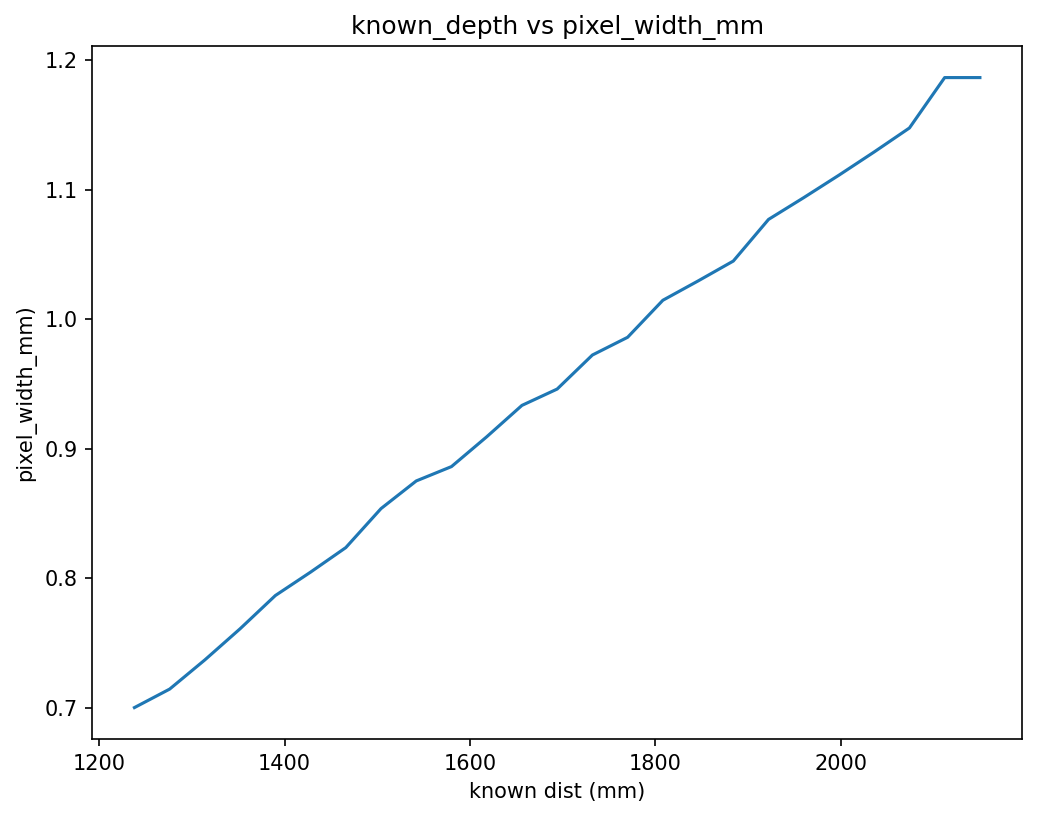

In [10]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_width_test['dist_mm'], df_depth_vs_px_width_test['pixel_width_mm'])
plt.title('known_depth vs pixel_width_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_width_mm)")

Text(0, 0.5, 'pixel_height_mm)')

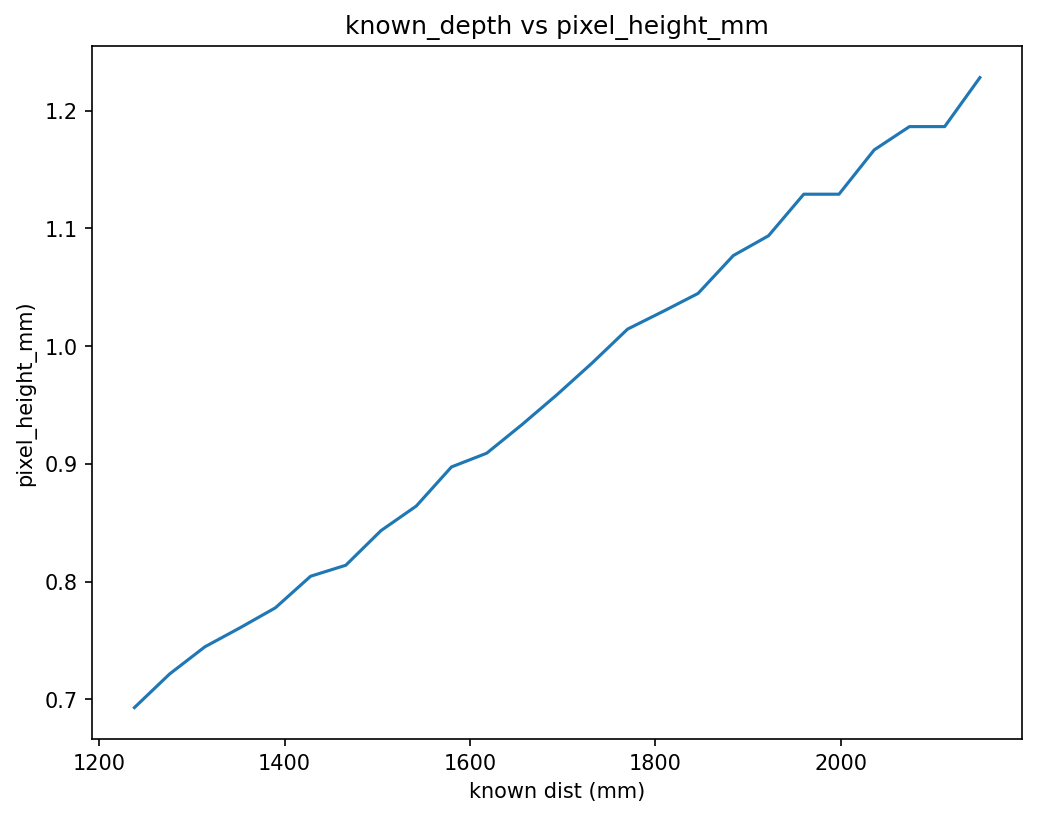

In [11]:
plt.figure (figsize=(8,6), dpi =150)
plt.plot(df_depth_vs_px_height_test['dist_mm'], df_depth_vs_px_height_test['pixel_height_mm'])
plt.title('known_depth vs pixel_height_mm')
plt.xlabel("known dist (mm)")
plt.ylabel("pixel_height_mm)")